# Cancer Patient Data Preprocessing & Model Training
Preprocessing, encoding, scaling, and training ML models for cancer prediction.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [13]:
df = pd.read_csv("../preprocessed/cancer_patient_preprocessed.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 25)


,patient_id,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,...,fatigue,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring,level
0,-1.730320,-0.347848,-0.819903,-0.906679,-0.214954,-0.083340,-0.398718,-0.743202,-1.288162,-1.167040,...,-0.381548,0.065746,-0.980760,-0.870694,-0.328743,-1.224625,-0.838618,-0.418550,0.728655,1
1,-1.726856,-1.681238,-0.819903,-0.413919,-1.360357,-0.083340,-0.873383,-0.272821,-1.288162,-1.167040,...,-1.273014,-0.387677,1.208436,2.069186,0.993281,-0.805663,-1.384593,1.544171,-0.628245,2
2,-1.723391,-0.181174,-0.819903,0.078842,0.166847,0.421751,0.075946,0.197560,-0.205673,0.706970,...,1.847119,1.426018,2.084114,-0.870694,-1.210093,0.032260,1.345283,1.544171,-0.628245,0
3,-1.719927,-0.014501,-0.819903,1.557123,0.930449,0.926842,1.025275,0.667941,1.418061,1.175473,...,0.064186,-0.841101,-0.542921,-1.360675,0.111931,0.451222,1.345283,1.544171,1.407105,0
4,-1.716463,0.735531,-0.819903,1.064362,1.312250,0.926842,1.025275,1.138323,0.876816,1.175473,...,-0.381548,-0.841101,-0.105081,-1.360675,0.111931,-0.805663,0.253332,-0.909231,0.050205,0


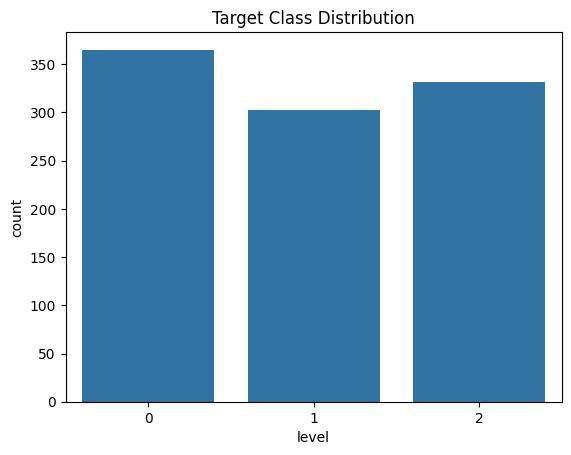

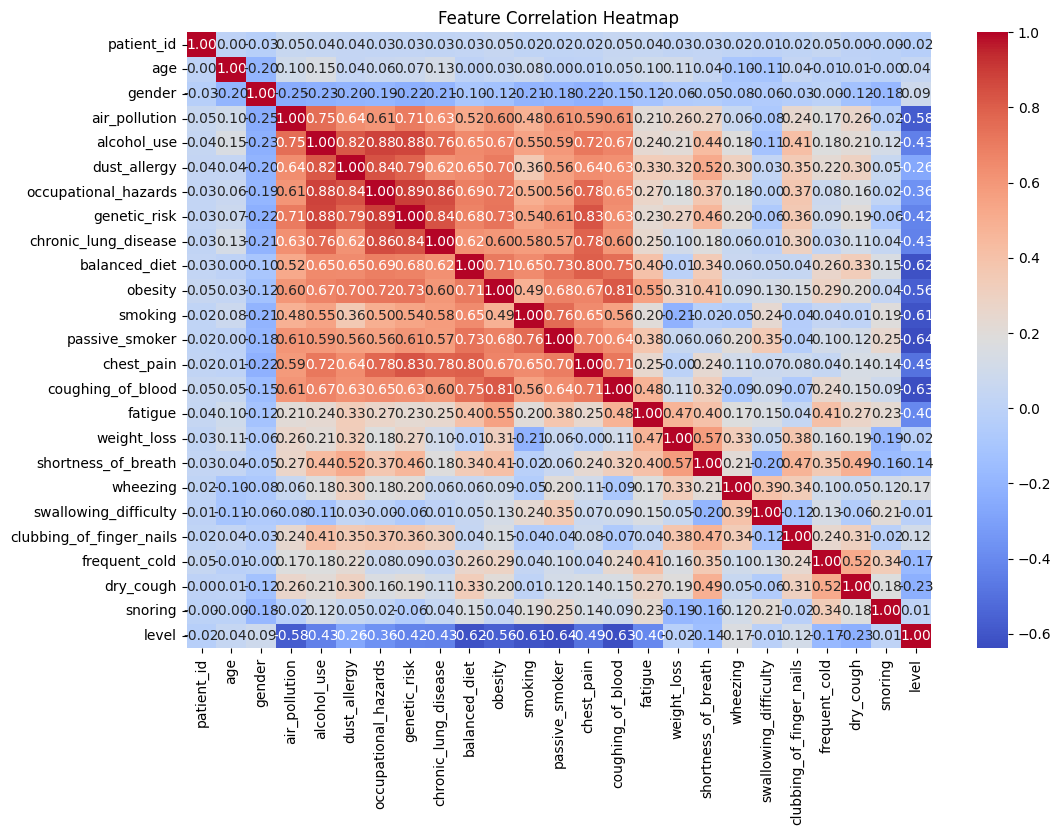

In [14]:
# Distribution of target
sns.countplot(x='level', data=df)
plt.title("Target Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [15]:

# Load the trained RandomForest model
model = joblib.load("../models/cancer_model.pkl")
print("Model loaded successfully")


Model loaded successfully


In [16]:
X = df.drop(columns=['level'])
y = df['level']


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       365
           1       1.00      1.00      1.00       303
           2       1.00      1.00      1.00       332

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



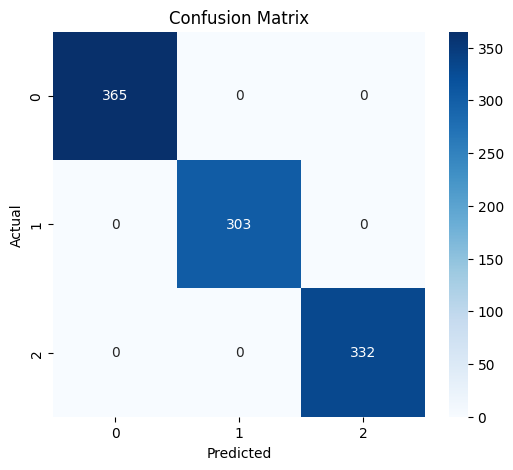

ROC AUC: N/A (not binary classification)


In [18]:
# Predictions
y_pred = model.predict(X)

# Accuracy & classification report
print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ROC AUC (if binary)
try:
    probs = model.predict_proba(X)[:,1]
    auc = roc_auc_score(y, probs)
    print("ROC AUC Score:", auc)
except:
    print("ROC AUC: N/A (not binary classification)")


In [19]:
# Adding predictions to dataset
df['predicted_level'] = y_pred
df.head()


,patient_id,age,gender,air_pollution,alcohol_use,dust_allergy,occupational_hazards,genetic_risk,chronic_lung_disease,balanced_diet,...,weight_loss,shortness_of_breath,wheezing,swallowing_difficulty,clubbing_of_finger_nails,frequent_cold,dry_cough,snoring,level,predicted_level
0,-1.730320,-0.347848,-0.819903,-0.906679,-0.214954,-0.083340,-0.398718,-0.743202,-1.288162,-1.167040,...,0.065746,-0.980760,-0.870694,-0.328743,-1.224625,-0.838618,-0.418550,0.728655,1,1
1,-1.726856,-1.681238,-0.819903,-0.413919,-1.360357,-0.083340,-0.873383,-0.272821,-1.288162,-1.167040,...,-0.387677,1.208436,2.069186,0.993281,-0.805663,-1.384593,1.544171,-0.628245,2,2
2,-1.723391,-0.181174,-0.819903,0.078842,0.166847,0.421751,0.075946,0.197560,-0.205673,0.706970,...,1.426018,2.084114,-0.870694,-1.210093,0.032260,1.345283,1.544171,-0.628245,0,0
3,-1.719927,-0.014501,-0.819903,1.557123,0.930449,0.926842,1.025275,0.667941,1.418061,1.175473,...,-0.841101,-0.542921,-1.360675,0.111931,0.451222,1.345283,1.544171,1.407105,0,0
4,-1.716463,0.735531,-0.819903,1.064362,1.312250,0.926842,1.025275,1.138323,0.876816,1.175473,...,-0.841101,-0.105081,-1.360675,0.111931,-0.805663,0.253332,-0.909231,0.050205,0,0


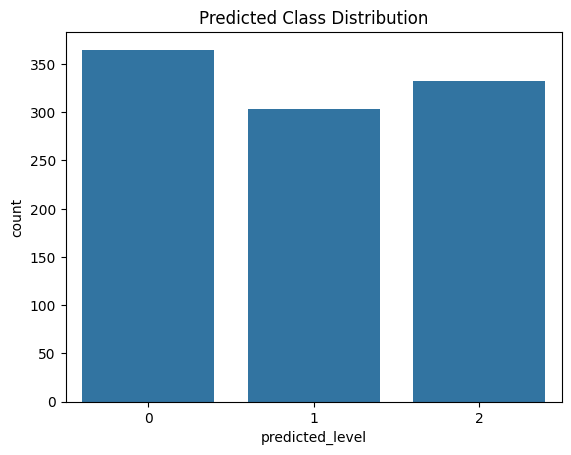

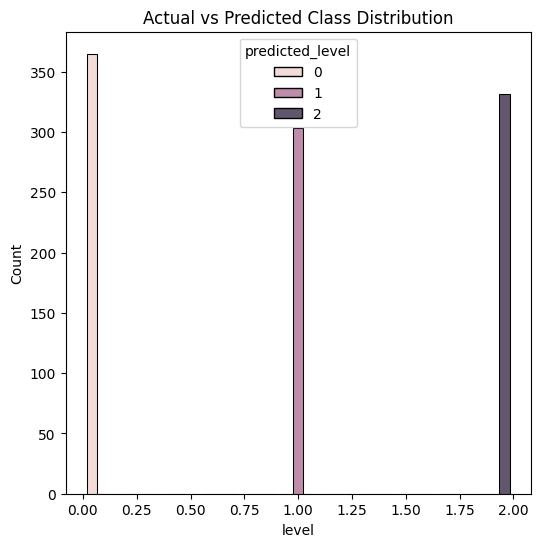

In [20]:
sns.countplot(x='predicted_level', data=df)
plt.title("Predicted Class Distribution")
plt.show()

# Compare actual vs predicted
plt.figure(figsize=(6,6))
sns.histplot(x='level', hue='predicted_level', data=df, multiple='dodge', shrink=0.8)
plt.title("Actual vs Predicted Class Distribution")
plt.show()
